# 03 — Lead Scoring

XGBoost + Logistic Regression on `inquired_to_applied`.  
70/15/15 stratified split · class weighting · Platt calibration · top-3 SHAP per lead.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from src.utils import set_seeds, SYNTHETIC_DIR, OUTPUT_DIR
import src.lead_model as lm

set_seeds()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(SYNTHETIC_DIR / 'applicants.csv')
print(f'Loaded {len(df):,} applicants. Lead rate: {df["inquired_to_applied"].mean():.1%}')

Loaded 50,000 applicants. Lead rate: 30.0%


## Train models

GridSearchCV (5-fold) over XGBoost hyperparameters. ~5–10 min on CPU.

In [2]:
artifact = lm.train(df)
print('Best XGBoost params:', artifact['metrics']['best_xgb_params'])

Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}


C:\Users\jeged\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\jeged\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


## Test-set performance

In [3]:
import json

for model_key, label in [('xgb', 'XGBoost'), ('lr', 'Logistic Regression')]:
    m = artifact['metrics'][model_key]
    print(f'\n{label}')
    print(f'  ROC-AUC : {m["roc_auc"]:.4f}')
    print(f'  PR-AUC  : {m["pr_auc"]:.4f}')
    print(f'  F1      : {m["f1"]:.4f}')
    print(f'  Prec    : {m["precision"]:.4f}')
    print(f'  Recall  : {m["recall"]:.4f}')
    print(f'  Conf. matrix: {m["confusion_matrix"]}')


XGBoost
  ROC-AUC : 0.6601
  PR-AUC  : 0.4460
  F1      : 0.2385
  Prec    : 0.5707
  Recall  : 0.1507
  Conf. matrix: [[4996, 255], [1910, 339]]

Logistic Regression
  ROC-AUC : 0.6648
  PR-AUC  : 0.4501
  F1      : 0.2314
  Prec    : 0.5667
  Recall  : 0.1454
  Conf. matrix: [[5001, 250], [1922, 327]]


## ROC & Precision-Recall curves

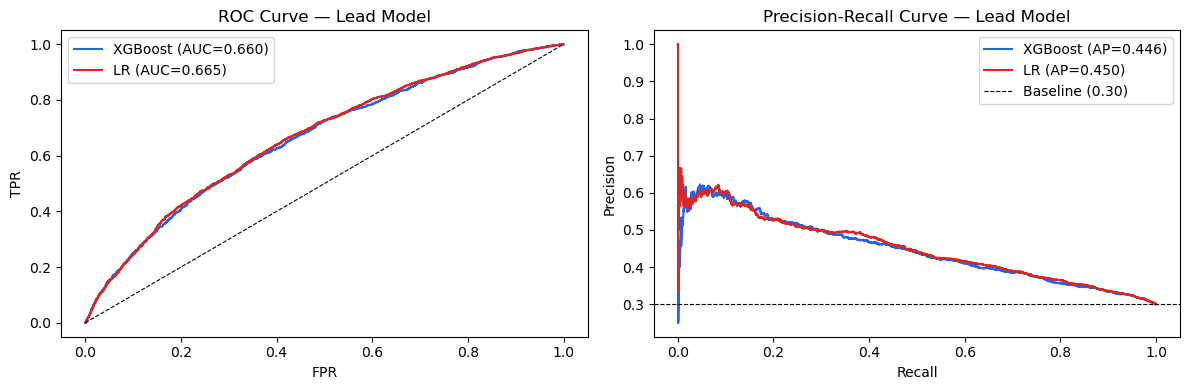

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve
import numpy as np

X_test = artifact['X_test']
y_test = artifact['y_test']

xgb_prob = artifact['xgb'].predict_proba(X_test)[:, 1]
lr_prob  = artifact['lr'].predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for prob, label, color in [(xgb_prob, 'XGBoost', '#2563eb'), (lr_prob, 'LR', '#dc2626')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    prec, rec, _ = precision_recall_curve(y_test, prob)
    from sklearn.metrics import roc_auc_score, average_precision_score
    auc = roc_auc_score(y_test, prob)
    ap  = average_precision_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color)
    axes[1].plot(rec, prec, label=f'{label} (AP={ap:.3f})', color=color)

axes[0].plot([0,1],[0,1],'k--', lw=0.8)
axes[0].set(title='ROC Curve — Lead Model', xlabel='FPR', ylabel='TPR')
axes[0].legend()

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=0.8, label=f'Baseline ({baseline:.2f})')
axes[1].set(title='Precision-Recall Curve — Lead Model', xlabel='Recall', ylabel='Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lead_roc_pr.png', bbox_inches='tight')
plt.show()

## Calibration plot

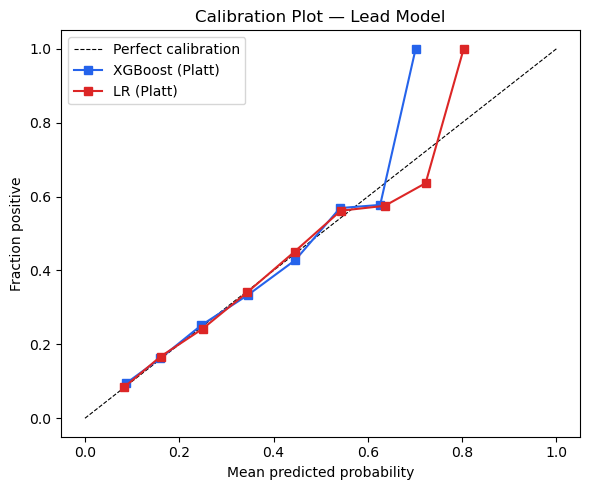

In [5]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect calibration')

for prob, label, color in [(xgb_prob, 'XGBoost (Platt)', '#2563eb'), (lr_prob, 'LR (Platt)', '#dc2626')]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', label=label, color=color)

ax.set(title='Calibration Plot — Lead Model', xlabel='Mean predicted probability', ylabel='Fraction positive')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lead_calibration.png', bbox_inches='tight')
plt.show()

## Score all 50k leads and save

In [6]:
predictions = lm.predict(artifact, df)
predictions_full = df[['applicant_id', 'institution_segment', 'race_ethnicity',
                        'gender', 'first_gen_flag', 'income_band',
                        'inquired_to_applied']].merge(predictions, on='applicant_id')

out_path = OUTPUT_DIR / 'lead_predictions.csv'
predictions_full.to_csv(out_path, index=False)
print(f'Saved {len(predictions_full):,} rows to {out_path}')
predictions_full[['lead_score', 'lead_probability']].describe().round(3)

Saved 50,000 rows to C:\Users\jeged\Downloads\Enrollment Decline & Demographic Shift AI System\data\output\lead_predictions.csv


,lead_score,lead_probability
count,50000.000,50000.000
mean,30.076,0.301
std,12.307,0.123
min,5.800,0.058
25%,20.300,0.203
50%,28.200,0.282
75%,38.200,0.382
max,70.400,0.704


## Score distribution

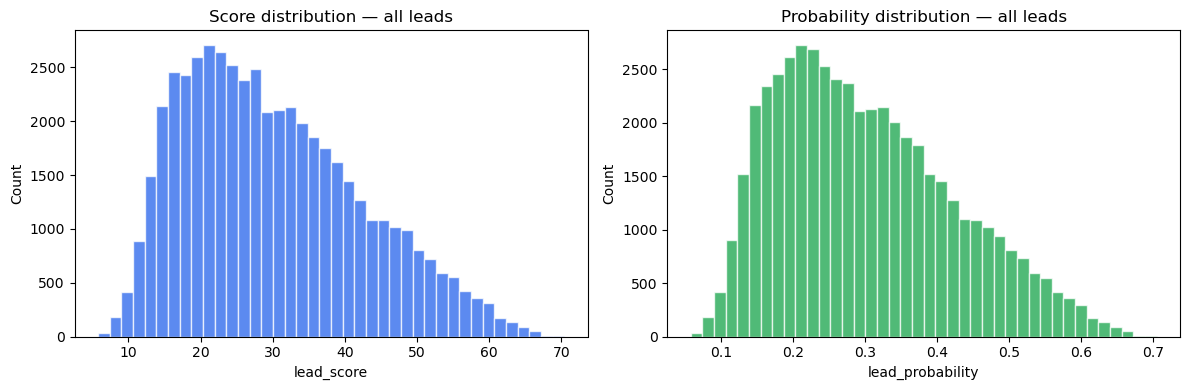


Top-10 leads:


,applicant_id,institution_segment,lead_score,shap_feature_1,shap_value_1,shap_feature_2,shap_value_2
32672,32672,R1,70.4,email_engagement_score,0.616,campus_visit_flag,0.5298
20625,20625,R1,70.3,hs_gpa,0.538,email_engagement_score,0.5249
35595,35595,R1,70.1,email_engagement_score,0.5957,campus_visit_flag,0.5235
5996,5996,private_lac,69.9,email_engagement_score,0.6344,campus_visit_flag,0.5331
12452,12452,private_lac,69.6,email_engagement_score,0.6227,campus_visit_flag,0.5234
12751,12751,R1,68.9,email_engagement_score,0.5992,campus_visit_flag,0.5604
32463,32463,regional_state,68.1,email_engagement_score,0.5404,campus_visit_flag,0.5178
20780,20780,private_lac,67.8,campus_visit_flag,0.5117,email_engagement_score,0.4695
2298,2298,R1,67.5,campus_visit_flag,0.598,source_channel_highschool_visit,0.3364
6867,6867,R1,67.5,email_engagement_score,0.5583,campus_visit_flag,0.5264


In [7]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color, title in [
    (axes[0], 'lead_score', '#2563eb', 'Score distribution — all leads'),
    (axes[1], 'lead_probability', '#16a34a', 'Probability distribution — all leads'),
]:
    ax.hist(predictions_full[col], bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.set(title=title, xlabel=col, ylabel='Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lead_score_dist.png', bbox_inches='tight')
plt.show()

print('\nTop-10 leads:')
predictions_full.nlargest(10, 'lead_score')[['applicant_id', 'institution_segment',
                                               'lead_score', 'shap_feature_1', 'shap_value_1',
                                               'shap_feature_2', 'shap_value_2']]

## Save model artifact

In [8]:
saved = lm.save(artifact)
print(f'Artifact saved to {saved}')

Artifact saved to C:\Users\jeged\Downloads\Enrollment Decline & Demographic Shift AI System\models\lead_scoring.pkl
